## Downscaling Specific Humidity
Assessing downscaling of specific humidity using the approach of Liston and Elder 2006

In [35]:
from buildforcing.datasets import siteNLDAS
import pandas as pd
import os
import xarray as xr
from datetime import datetime
from metpy.calc import dewpoint_from_specific_humidity, relative_humidity_from_dewpoint, relative_humidity_from_specific_humidity, dewpoint_from_relative_humidity
from metpy.calc import specific_humidity_from_dewpoint
from metpy.units import units
import numpy as np
import matplotlib.pyplot as plt

Load the NLDAS and GAMUT data at Tony Grove for algorithm testing.

In [2]:
environment = 'C:/Users/clmbn/NMT_PhD/data/'

In [3]:
# Tony Grove Parameters
lat = 41.89
lon = -111.57
elev = 1930.5 # meter from Snotel dataset 6332 ft

In [4]:
nldas = siteNLDAS(latitude=lat, longitude=lon, start_date=datetime(2015,10,1), end_date=datetime(2016,10,1))
nldas.loadNetCDF(os.path.join(environment,'nldas'))

In [5]:
nldas_topography = xr.open_dataset(os.path.join(environment, 'nldas', f'NLDAS_elevation.nc4'))

# Get the elevation at the site
nldas_elevation = nldas_topography.sel(lat=lat, lon=lon, method='nearest').NLDAS_elev.values.item()
nldas_topography.close()
print(f'NLDAS Elevation at site: {nldas_elevation} m')

NLDAS Elevation at site: 2328.907958984375 m


In [6]:
# Print nldas forcing and units for reference
forcing_units = zip(nldas.nldas_forcings, nldas.forcing_units)
for forcing, unit in forcing_units:
    print(f"{forcing}: {unit}")

LWdown: W/m^2
PSurf: Pa
Qair: kg/kg
Rainf: kg/m2
SWdown: W/m^2
Tair: K
Wind_E: m/s
Wind_N: m/s


In [7]:
nldas_humidity = nldas.data.loc[:,['Qair','PSurf','Tair']]

### Approach
I will first calculate dew point temperature from the NLDAS specific humidity and temperature data. Then I will downscale the dew point following the lapse rate specified by Liston and Elder (2006). Finally, I will convert the downscaled dew point back to specific humidity based on the downscaled temperature. I could use the site corrected temperature to convert back to specific humidity, but Enrico recommends using the downscaled temperature instead to be consistent with the downscaling approach.

In [9]:
# Calculate relative humidity using NLDAS specific humidity for reference
nldas_humidity['RH'] = relative_humidity_from_specific_humidity(
    nldas_humidity['PSurf'].values * units('Pa'),
    nldas_humidity['Tair'].values * units('K'),
    nldas_humidity['Qair'].values * units('kg/kg')
).magnitude * 100  # Convert to percentage

In [10]:
# Calculate dewpoint
nldas_humidity['Dewpoint'] = dewpoint_from_specific_humidity(nldas_humidity.PSurf.values * units.Pa, nldas_humidity.Qair.values * units('kg/kg')).magnitude

In [11]:
# Lapse rate function from Liston and Elder (2006). 
def lapse_rate(dt: pd.DatetimeIndex, lapse_type='T') -> np.ndarray:
    '''
    Calculate the lapse rate as a function of the month of the year.
    lapse_type: 'T' for temperature lapse rate, 'D' for dewpoint lapse rate.
    See Liston and Elder (2006) for details.

    For dew point lapse rate, the formula is:
    gamma_d = lambda * c/b
    '''
    if lapse_type not in ['T', 'D']:
        raise ValueError("lapse_type must be 'T' for temperature or 'D' for dewpoint.")

    # Parameters for lapse rate (T [C/km], lambda [km^-1])
    monthly_parameter = [
        (4.4, 0.41),  # January
        (5.9, 0.42),  # February
        (7.1, 0.40),  # March
        (7.8, 0.39),  # April
        (8.1, 0.38),  # May
        (8.2, 0.36),  # June
        (8.1, 0.33),  # July
        (8.1, 0.33),  # August
        (7.7, 0.36),  # September
        (6.8, 0.37),  # October
        (5.5, 0.40),  # November
        (4.7, 0.40)   # December
    ]
    c = 240.97  # C
    b = 17.502  # dimensionless 

    months = dt.month.values - 1  # Convert to zero-based index

    if lapse_type == 'T':
        return np.array([monthly_parameter[m][0] for m in months])
    elif lapse_type == 'D':
        return np.array([monthly_parameter[m][1] * c / b for m in months])

In [12]:
nldas_humidity['DewLapseRate'] = lapse_rate(nldas_humidity.index, lapse_type='D')
nldas_humidity['TempLapseRate'] = lapse_rate(nldas_humidity.index, lapse_type='T')

In [13]:
# Calculate downscaled dewpoint
dz = (elev - nldas_elevation)/1000  # Difference in elevation (km)
nldas_humidity['DewpointDownscaled'] = nldas_humidity.Dewpoint - nldas_humidity.DewLapseRate * dz
nldas_humidity['TDownscaled'] = nldas_humidity.Tair - nldas_humidity.TempLapseRate * dz

In [14]:
# Calculate relative humidity
nldas_humidity['DownscaledRH'] = relative_humidity_from_dewpoint(
    nldas_humidity.TDownscaled.values * units.degK,
    nldas_humidity.DewpointDownscaled.values * units.degC
).magnitude*100  # Convert to percentage

Compare to GAMUT data.

In [15]:
# Load the GAMUT HC2S3 Sensor data
gamut_HC2S3 = pd.read_csv(
    os.path.join(environment, 'gamut', 'tonygrovers', 'LR_TG_C_RH_HC2S3_SourceID_1_QC_1.csv'),
    skiprows=55
)

gamut_HC2S3.index = pd.DatetimeIndex(
    pd.to_datetime(gamut_HC2S3['LocalDateTime'], format='%Y-%m-%d %H:%M:%S')
)
gamut_HC2S3.index = gamut_HC2S3.index + pd.Timedelta(hours=7)  # Adjust for UTC-7
gamut_HC2S3.index = gamut_HC2S3.index.tz_localize('UTC')

In [16]:
gamut_HC2S3 = gamut_HC2S3.replace(-9999, np.nan)

In [17]:
# Only need data from 2015-10-01 to 2016-10-01
gamut_HC2S3 = gamut_HC2S3.loc['2015-10-01':'2016-10-01']

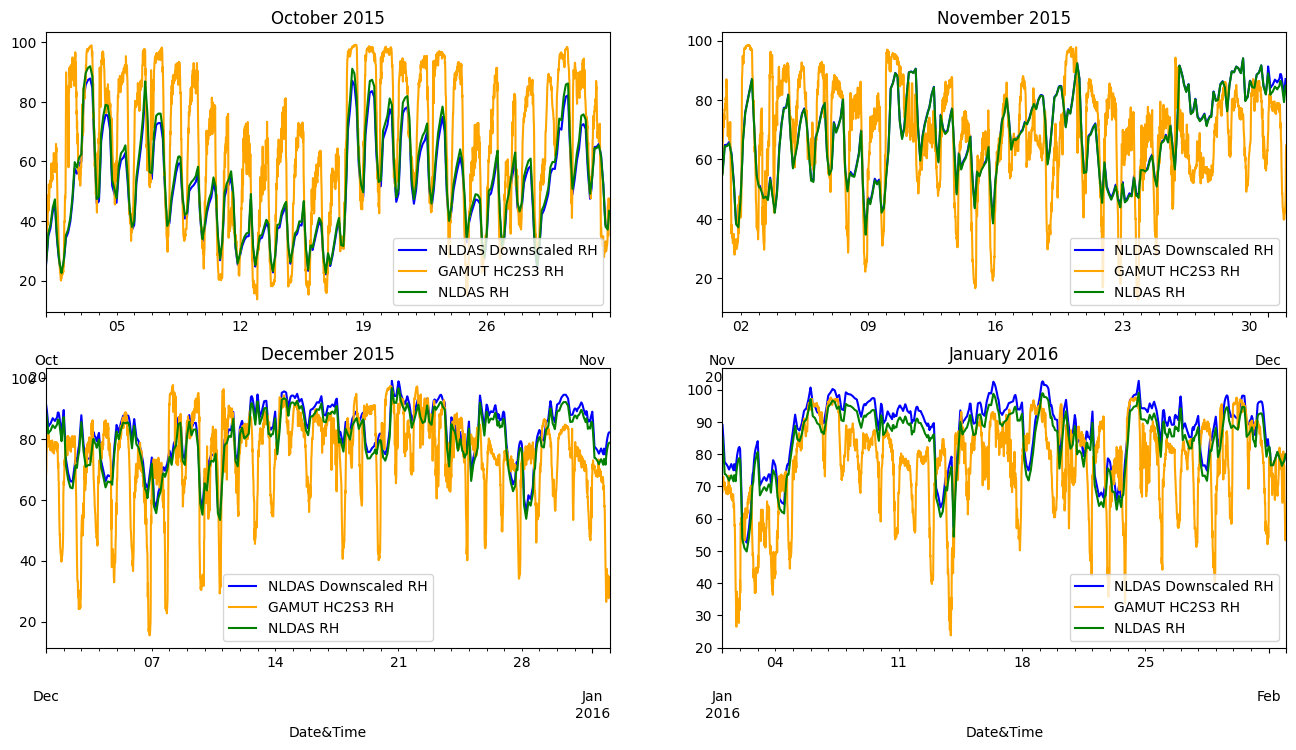

In [18]:
fig, axs = plt.subplots(2, 2, figsize=(16, 8))
# Plot one month per subplot
nldas_humidity.loc['2015-10-01':'2015-11-01', 'DownscaledRH'].plot(ax=axs[0, 0], label='NLDAS Downscaled RH', color='blue')
gamut_HC2S3.loc['2015-10-01':'2015-11-01', 'RH_HC2S3'].plot(ax=axs[0, 0], label='GAMUT HC2S3 RH', color='orange')
nldas_humidity.loc['2015-10-01':'2015-11-01', 'RH'].plot(ax=axs[0, 0], label='NLDAS RH', color='green')
axs[0, 0].set_title('October 2015')

nldas_humidity.loc['2015-11-01':'2015-12-01', 'DownscaledRH'].plot(ax=axs[0, 1], label='NLDAS Downscaled RH', color='blue')
gamut_HC2S3.loc['2015-11-01':'2015-12-01', 'RH_HC2S3'].plot(ax=axs[0, 1], label='GAMUT HC2S3 RH', color='orange')
nldas_humidity.loc['2015-11-01':'2015-12-01', 'RH'].plot(ax=axs[0, 1], label='NLDAS RH', color='green')
axs[0, 1].set_title('November 2015')

nldas_humidity.loc['2015-12-01':'2016-01-01', 'DownscaledRH'].plot(ax=axs[1, 0], label='NLDAS Downscaled RH', color='blue')
gamut_HC2S3.loc['2015-12-01':'2016-01-01', 'RH_HC2S3'].plot(ax=axs[1, 0], label='GAMUT HC2S3 RH', color='orange')
nldas_humidity.loc['2015-12-01':'2016-01-01', 'RH'].plot(ax=axs[1, 0], label='NLDAS RH', color='green')
axs[1, 0].set_title('December 2015')

nldas_humidity.loc['2016-01-01':'2016-02-01', 'DownscaledRH'].plot(ax=axs[1, 1], label='NLDAS Downscaled RH', color='blue')
gamut_HC2S3.loc['2016-01-01':'2016-02-01', 'RH_HC2S3'].plot(ax=axs[1, 1], label='GAMUT HC2S3 RH', color='orange')
nldas_humidity.loc['2016-01-01':'2016-02-01', 'RH'].plot(ax=axs[1, 1], label='NLDAS RH', color='green')
axs[1, 1].set_title('January 2016')

# Add legends to all subplots
for ax in axs.flat:
    ax.legend()

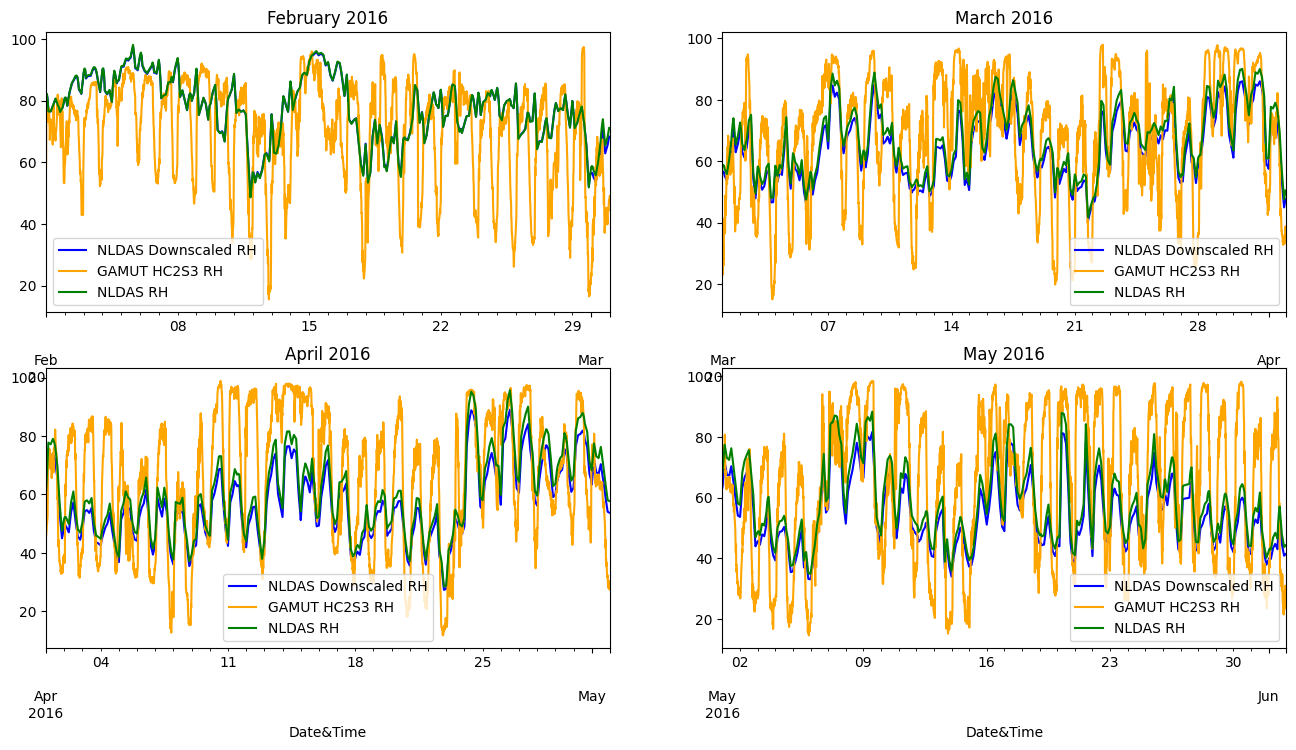

In [19]:
fig, axs = plt.subplots(2, 2, figsize=(16, 8))
# Plot one month per subplot
nldas_humidity.loc['2016-02-01':'2016-03-01', 'DownscaledRH'].plot(ax=axs[0, 0], label='NLDAS Downscaled RH', color='blue')
gamut_HC2S3.loc['2016-02-01':'2016-03-01', 'RH_HC2S3'].plot(ax=axs[0, 0], label='GAMUT HC2S3 RH', color='orange')
nldas_humidity.loc['2016-02-01':'2016-03-01', 'RH'].plot(ax=axs[0, 0], label='NLDAS RH', color='green')
axs[0, 0].set_title('February 2016')

nldas_humidity.loc['2016-03-01':'2016-04-01', 'DownscaledRH'].plot(ax=axs[0, 1], label='NLDAS Downscaled RH', color='blue')
gamut_HC2S3.loc['2016-03-01':'2016-04-01', 'RH_HC2S3'].plot(ax=axs[0, 1], label='GAMUT HC2S3 RH', color='orange')
nldas_humidity.loc['2016-03-01':'2016-04-01', 'RH'].plot(ax=axs[0, 1], label='NLDAS RH', color='green')
axs[0, 1].set_title('March 2016')

nldas_humidity.loc['2016-04-01':'2016-05-01', 'DownscaledRH'].plot(ax=axs[1, 0], label='NLDAS Downscaled RH', color='blue')
gamut_HC2S3.loc['2016-04-01':'2016-05-01', 'RH_HC2S3'].plot(ax=axs[1, 0], label='GAMUT HC2S3 RH', color='orange')
nldas_humidity.loc['2016-04-01':'2016-05-01', 'RH'].plot(ax=axs[1, 0], label='NLDAS RH', color='green')
axs[1, 0].set_title('April 2016')

nldas_humidity.loc['2016-05-01':'2016-06-01', 'DownscaledRH'].plot(ax=axs[1, 1], label='NLDAS Downscaled RH', color='blue')
gamut_HC2S3.loc['2016-05-01':'2016-06-01', 'RH_HC2S3'].plot(ax=axs[1, 1], label='GAMUT HC2S3 RH', color='orange')
nldas_humidity.loc['2016-05-01':'2016-06-01', 'RH'].plot(ax=axs[1, 1], label='NLDAS RH', color='green')
axs[1, 1].set_title('May 2016')

# Add legends to all subplots
for ax in axs.flat:
    ax.legend()

The downscaled NLDAS humidity is not that different from the original NLDAS humidity, maybe because this site is not very different from the NLDAS grid cell.

### Compare specific humidities

In [20]:
# Load GAMUT pressure data
gamut_bp = pd.read_csv(
    os.path.join(environment, 'gamut', 'tonygrovers', 'LR_TG_C_BP_Avg_SourceID_1_QC_1.csv'),
    skiprows=55
)

gamut_bp.index = pd.DatetimeIndex(
    pd.to_datetime(gamut_bp
['LocalDateTime'], format='%Y-%m-%d %H:%M:%S')
)
gamut_bp.index = gamut_bp.index + pd.Timedelta(hours=7)  # Adjust for UTC-7
gamut_bp.index = gamut_bp.index.tz_localize('UTC')

In [27]:
# Load GAMUT temperature data from ST110
gamut_ST110 = pd.read_csv(
    os.path.join(environment, 'gamut', 'tonygrovers', 'LR_TG_C_AirTemp_ST110_Avg_SourceID_1_QC_1.csv'),
    skiprows=56
)
gamut_ST110.index = pd.DatetimeIndex(
    pd.to_datetime(gamut_ST110['LocalDateTime'], format='%Y-%m-%d %H:%M:%S')
)
gamut_ST110.index = gamut_ST110.index + pd.Timedelta(hours=7)  # Adjust for UTC-7
gamut_ST110.index = gamut_ST110.index.tz_localize('UTC')

In [32]:
# Join with HC2S3 data
gamut_data = pd.merge(gamut_HC2S3.loc[:,'RH_HC2S3'],gamut_bp.loc[:,'BP_Avg'],how='left',left_index=True, right_index=True)
gamut_data = pd.merge(gamut_data, gamut_ST110.loc[:,'AirTemp_ST110_Avg'], how='left', left_index=True, right_index=True)

In [33]:
# Remove any -9999 values
gamut_data = gamut_data.replace(-9999, np.nan)

In [34]:
# Calculate dewpoint from GAMUT data
gamut_data['Dewpoint'] = dewpoint_from_relative_humidity(
    gamut_data['AirTemp_ST110_Avg'].values * units.degC,
    gamut_data['RH_HC2S3'].values * units.percent
).magnitude

In [36]:
# Calculate specific humidity from GAMUT pressure and relative humidity
gamut_data['Qair'] = specific_humidity_from_dewpoint(
    gamut_data['BP_Avg'].values * units.kPa,
    gamut_data['Dewpoint'].values * units.degC
).to('kg/kg').magnitude

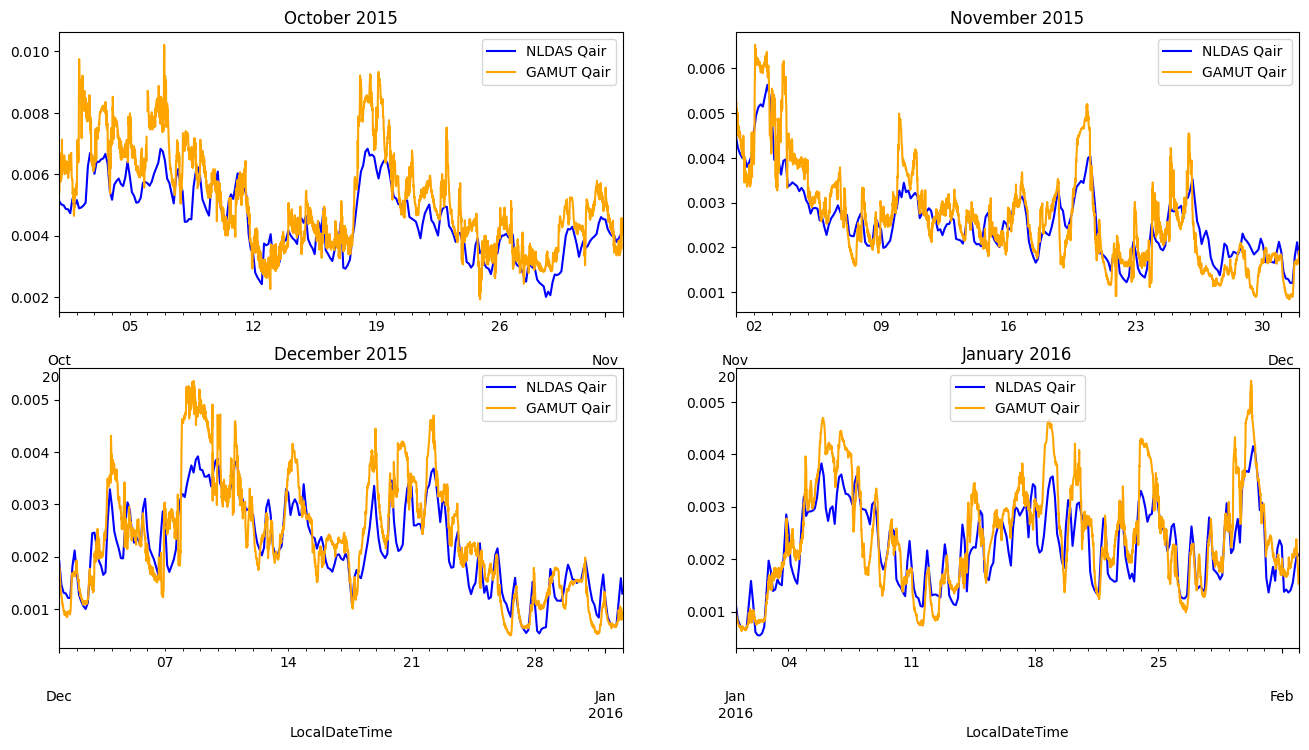

In [37]:
fig, axs = plt.subplots(2, 2, figsize=(16, 8))
# Plot one month per subplot
nldas_humidity.loc['2015-10-01':'2015-11-01', 'Qair'].plot(ax=axs[0, 0], label='NLDAS Qair', color='blue')
gamut_data.loc['2015-10-01':'2015-11-01', 'Qair'].plot(ax=axs[0, 0], label='GAMUT Qair', color='orange')
axs[0, 0].set_title('October 2015')

nldas_humidity.loc['2015-11-01':'2015-12-01', 'Qair'].plot(ax=axs[0, 1], label='NLDAS Qair', color='blue')
gamut_data.loc['2015-11-01':'2015-12-01', 'Qair'].plot(ax=axs[0, 1], label='GAMUT Qair', color='orange')
axs[0, 1].set_title('November 2015')

nldas_humidity.loc['2015-12-01':'2016-01-01', 'Qair'].plot(ax=axs[1, 0], label='NLDAS Qair', color='blue')
gamut_data.loc['2015-12-01':'2016-01-01', 'Qair'].plot(ax=axs[1, 0], label='GAMUT Qair', color='orange')
axs[1, 0].set_title('December 2015')

nldas_humidity.loc['2016-01-01':'2016-02-01', 'Qair'].plot(ax=axs[1, 1], label='NLDAS Qair', color='blue')
gamut_data.loc['2016-01-01':'2016-02-01', 'Qair'].plot(ax=axs[1, 1], label='GAMUT Qair', color='orange')
axs[1, 1].set_title('January 2016')

# Add legends to all subplots
for ax in axs.flat:
    ax.legend()
